In [1]:
import pandas as pd

df = pd.read_csv("education_africa_cleaned.csv")

df_long = df.melt(
    id_vars=["country", "government", "year"],
    value_vars=[
        "school_enrollment,_primary_%_gross",
        "school_enrollment,_secondary_%_gross",
        "school_enrollment,_tertiary_%_gross"
    ],
    var_name="education_level",
    value_name="enrollment"
)

In [2]:
df_long = df_long[df_long["year"] >= 2010]

In [3]:
df_long = df_long.dropna(subset=["enrollment"])

In [4]:
df_long["education_level"] = df_long["education_level"].str.replace(
    "school_enrollment,_", ""
).str.replace("_%_gross", "").str.capitalize()

In [18]:
def simplify(gov):
    gov = gov.lower()
    if "semi-presidential" in gov:
        return "semi-presidential"
    elif "presidential" in gov:
        return "presidential"
    elif "parliamentary" in gov:
        return "parliamentary"
    elif "monarchy" in gov:
        return "monarchy"
    else:
        return "other"

df_long["system_type"] = df_long["government"].apply(simplify)

In [7]:
df_final = df_long.groupby(
    ["country", "system_type", "education_level"]
)["enrollment"].mean().reset_index()

In [8]:
df_final["system_type"].value_counts()

system_type
presidential         100
semi-presidential     30
parliamentary         12
Name: count, dtype: int64

In [9]:
df_final.head()

,country,system_type,education_level,enrollment
0,Algeria,semi-presidential,Primary,108.667575
1,Algeria,semi-presidential,Secondary,102.980669
2,Algeria,semi-presidential,Tertiary,45.145177
3,Angola,presidential,Primary,107.760241
4,Angola,presidential,Secondary,43.386723


In [11]:
!pip install seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 13.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 13.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [seaborn]m5/6 [seaborn]ib]


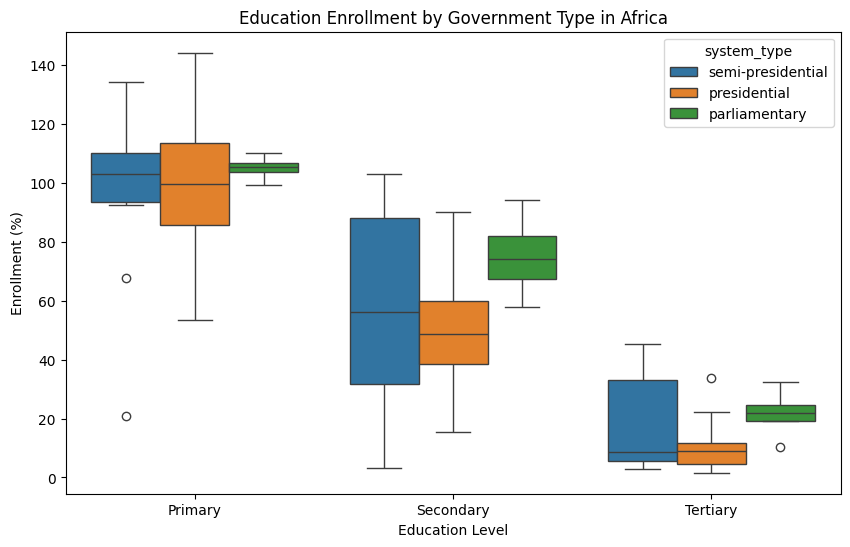

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    x="education_level",
    y="enrollment",
    hue="system_type",
    data=df_final
)

plt.title("Education Enrollment by Government Type in Africa")
plt.xlabel("Education Level")
plt.ylabel("Enrollment (%)")

plt.show()

In [13]:
df_time = df_long.groupby(
    ["year", "system_type", "education_level"]
)["enrollment"].mean().reset_index()

In [14]:
df_sec = df_time[df_time["education_level"] == "Secondary"]

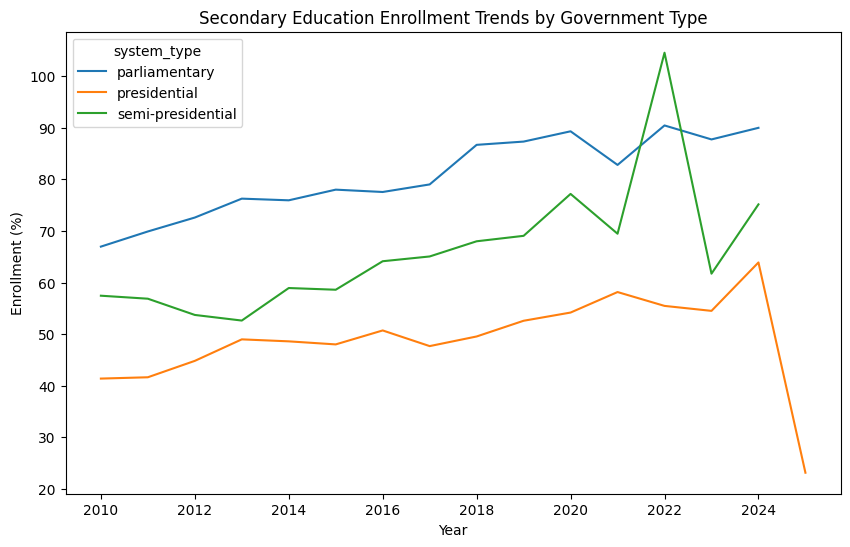

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.lineplot(
    x="year",
    y="enrollment",
    hue="system_type",
    data=df_sec
)

plt.title("Secondary Education Enrollment Trends by Government Type")
plt.xlabel("Year")
plt.ylabel("Enrollment (%)")

plt.show()

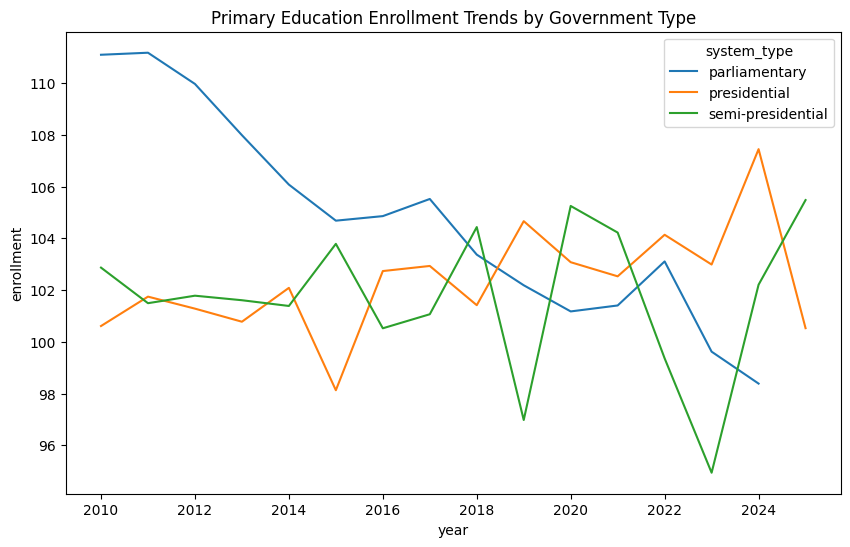

In [16]:
df_primary = df_time[df_time["education_level"] == "Primary"]

plt.figure(figsize=(10,6))
sns.lineplot(x="year", y="enrollment", hue="system_type", data=df_primary)

plt.title("Primary Education Enrollment Trends by Government Type")
plt.show()

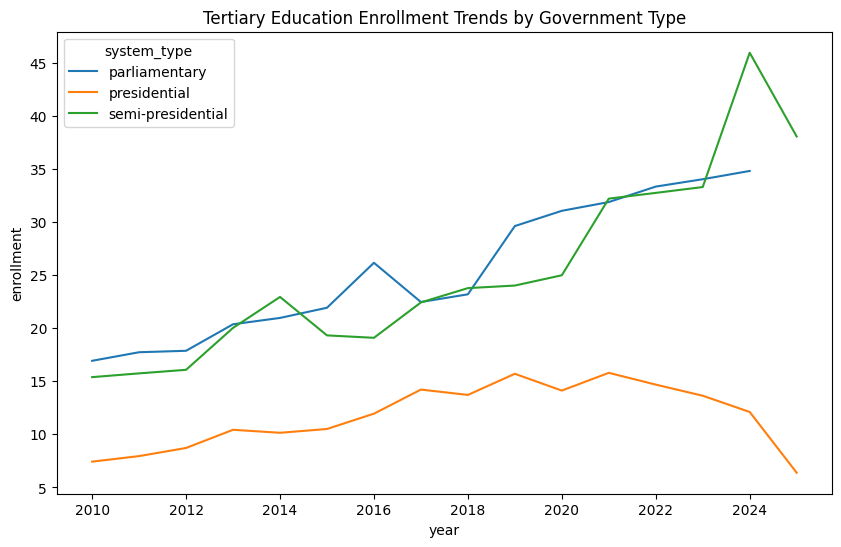

In [17]:
df_tertiary = df_time[df_time["education_level"] == "Tertiary"]

plt.figure(figsize=(10,6))
sns.lineplot(x="year", y="enrollment", hue="system_type", data=df_tertiary)

plt.title("Tertiary Education Enrollment Trends by Government Type")
plt.show()

In [19]:
plt.savefig("figures/boxplot_enrollment.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/primary_trend.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/secondary_trend.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/tertiary_trend.png", dpi=300, bbox_inches="tight")

FileNotFoundError: [Errno 2] No such file or directory: 'figures/boxplot_enrollment.png'

<Figure size 640x480 with 0 Axes>